In [37]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [38]:

# @st.cache_data
def load_data():
    df = pd.read_csv("../data/df_final.csv") 
    return df

df = load_data()

In [39]:
df.head()

,review_text,clean_text,review_date,clean_length,tokenized,sentiment_label,dominant_topic
0,barang bagus proses cepat,barang bagus proses cepat,2025-07-11,4,"['barang', 'bagus', 'proses', 'cepat']",positive,Accurate Orders
1,Bagus sesuai,bagus sesuai,2025-03-07,2,"['bagus', 'sesuai']",positive,Accurate Orders
2,Cepat kirimnya dalam sejam. Porsi medium cukup...,cepat kirimnya dalam sejam porsi medium cukup ...,2021-09-04,11,"['cepat', 'kirimnya', 'dalam', 'sejam', 'porsi...",positive,Fast Delivery & Packaging
3,"kaos kakinya nyaman dipake, rubber di bagian b...",kaos kakinya nyaman dipakai rubber di bagian b...,2024-07-15,12,"['kaos', 'kakinya', 'nyaman', 'dipakai', 'rubb...",positive,Good Product Quality
4,Pengiriman lama sekali padahal jarak begitu dekat,pengiriman lama sekali padahal jarak begitu dekat,2022-09-07,7,"['pengiriman', 'lama', 'sekali', 'padahal', 'j...",neutral,NaN


In [40]:
import matplotlib.dates as mdates

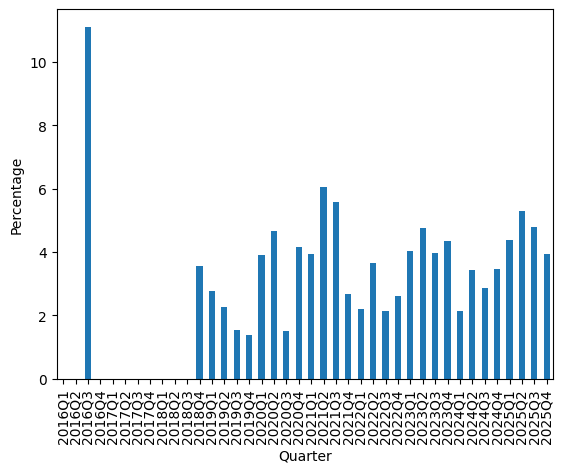

In [42]:
df["review_date"] = pd.to_datetime(df["review_date"])
df["quarter"] = df["review_date"].dt.to_period("Q")

negative_by_quarter = df[df["sentiment_label"] == "negative"].groupby("quarter").size()
# negative percentage
negative_by_quarter = negative_by_quarter / df.groupby("quarter").size() * 100

fig, ax = plt.subplots()
negative_by_quarter.plot(kind="bar", ax=ax)

# ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
# ax.xaxis.set_major_formatter(mdates.DateFormatter(''))

ax.set_xlabel("Quarter")
ax.set_ylabel("Percentage")
plt.show()


In [43]:
def without_hue(plot, feature, yp=20):
    total = len(feature)
    for p in ax.patches:
        percentage = '{:.1f}%'.format(100 * p.get_height()/total)
        x = p.get_x() + p.get_width() / 2 - 0.08
        y = p.get_y() + p.get_height() + yp
        ax.annotate(percentage, (x, y), size = 10)
    plt.show()

C:\Users\ACER\AppData\Local\Temp\ipykernel_24340\966829285.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="dominant_topic", data=neg_df, palette="muted")


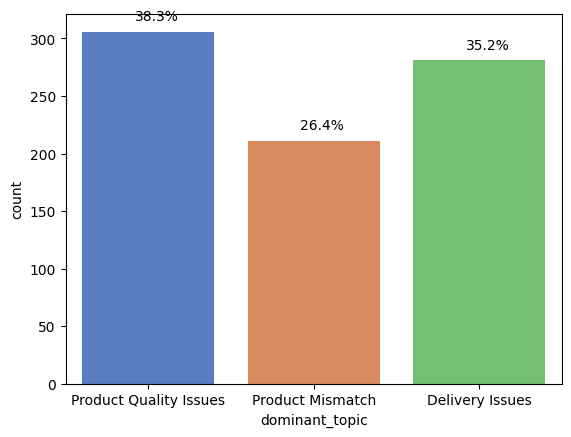

In [ ]:
fig, ax = plt.subplots()
neg_df = df[df["sentiment_label"] == "negative"]
sns.countplot(x="dominant_topic", data=neg_df, palette="muted")

without_hue(ax, neg_df["dominant_topic"], yp=10)

ax.set_xlabel("Topic")
ax.set_ylabel("Count")

plt.show()

In [51]:
def sparse_to_array(X):
    return X.toarray()

import joblib

def load_model():
    model_lr = joblib.load('../models/basic_model_lr.joblib')
    return model_lr

model = load_model()

In [55]:

labels = model.classes_.tolist()


df["sentiment_label"].value_counts(normalize=True).reindex(labels).fillna(0)

sentiment_label
negative    0.036958
neutral     0.037097
positive    0.925945
Name: proportion, dtype: float64